# Diseñaron una proteína desde cero. Funcionó en un ratón vivo.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

Tomaron un computador, lo apuntaron a un receptor que vive en la superficie de las células humanas, y le dijeron: *hazme una proteína nueva que se pegue a esto y lo active*. Lo que salió funcionó. No solo en un tubo de ensayo — funcionó en ratones, moviendo células madre tan bien (o mejor) que el fármaco aprobado por la FDA.

**Paper**: [De novo design of miniproteins targeting GPCRs](https://doi.org/10.1038/s41586-026-10656-8) · *Nature, 2026*
**DOI**: `10.1038/s41586-026-10656-8`
**Video del canal**: [Ver en YouTube](https://youtube.com/shorts/4L6OKRbUD6g)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-05-28-miniproteinas-gpcr-diseno-de-novo/notebook.ipynb)

## El contexto

Los **GPCRs** (receptores acoplados a proteína G) son los porteros químicos de tus células: detectan hormonas, neurotransmisores, sabores, olores. El 34 por ciento de los medicamentos aprobados por la FDA actúan sobre ellos — incluyendo Ozempic, Mozobil, los antihistamínicos.

El problema clásico: diseñar una molécula nueva que se pegue a un GPCR específico es caro y lento. Casi siempre el camino es buscar entre millones de moléculas químicas hasta encontrar una que pegue.

Este equipo hizo algo distinto. En vez de buscar, **diseñaron desde cero** miniproteínas (~50-80 aminoácidos) usando los modelos generativos RFdiffusion y ProteinMPNN. Probaron 4 receptores con funciones muy diferentes: picor (MRGPRX1), inflamación y movilización de células madre (CXCR4), diabetes (GLP1R) y obesidad (GIPR).

El receptor estrella aquí es **CXCR4**. El fármaco aprobado se llama AMD3100 (Mozobil) y lo usan oncólogos para sacar células madre hematopoyéticas (las que originan la sangre) de la médula ósea hacia el torrente sanguíneo, antes de un trasplante. ¿Logra hacer lo mismo una miniproteína diseñada en un computador?

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
FUENTE = 'Fuente: Vázquez Torres et al. (2026), Nature | Datos: Source Data MOESM3'
COLOR_DESIGN = '#2563EB'        # dCX1_001 (miniproteína diseñada)
COLOR_FDA    = '#DC2626'        # AMD3100 (fármaco FDA Mozobil)
COLOR_CONTROL = '#BBBBBB'       # PBS (control vehículo)
COLOR_NATURAL = '#059669'       # CXCL12 (ligando natural)
COLOR_REFERENCIA = '#D97706'    # líneas de referencia

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Cargar estilo CaM (local → fallback GitHub raw)
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

os.makedirs('figuras', exist_ok=True)

# Cargar datasets (paper Source Data MOESM3, tablas extraídas a CSV)
hsc = pd.read_csv('datos/hsc_mobilization_timecourse.csv')
hsc_stats = pd.read_csv('datos/hsc_pairwise_stats.csv')
cxcr4 = pd.read_csv('datos/cxcr4_antagonism.csv')

print(f'Movilización de células madre in vivo: {len(hsc)} ratones · {hsc.timepoint.nunique()} puntos temporales · {hsc.group.nunique()} grupos')
print(f'Antagonismo de CXCR4 in vitro: {len(cxcr4)} mediciones · {cxcr4.antagonist_concentration.nunique()} condiciones')
print(f'Estadística pareada del paper: {len(hsc_stats)} comparaciones (corrección de Sidak)')

Movilización de células madre in vivo: 135 ratones · 9 puntos temporales · 3 grupos
Antagonismo de CXCR4 in vitro: 96 mediciones · 3 condiciones
Estadística pareada del paper: 18 comparaciones (corrección de Sidak)


## Aquí está.

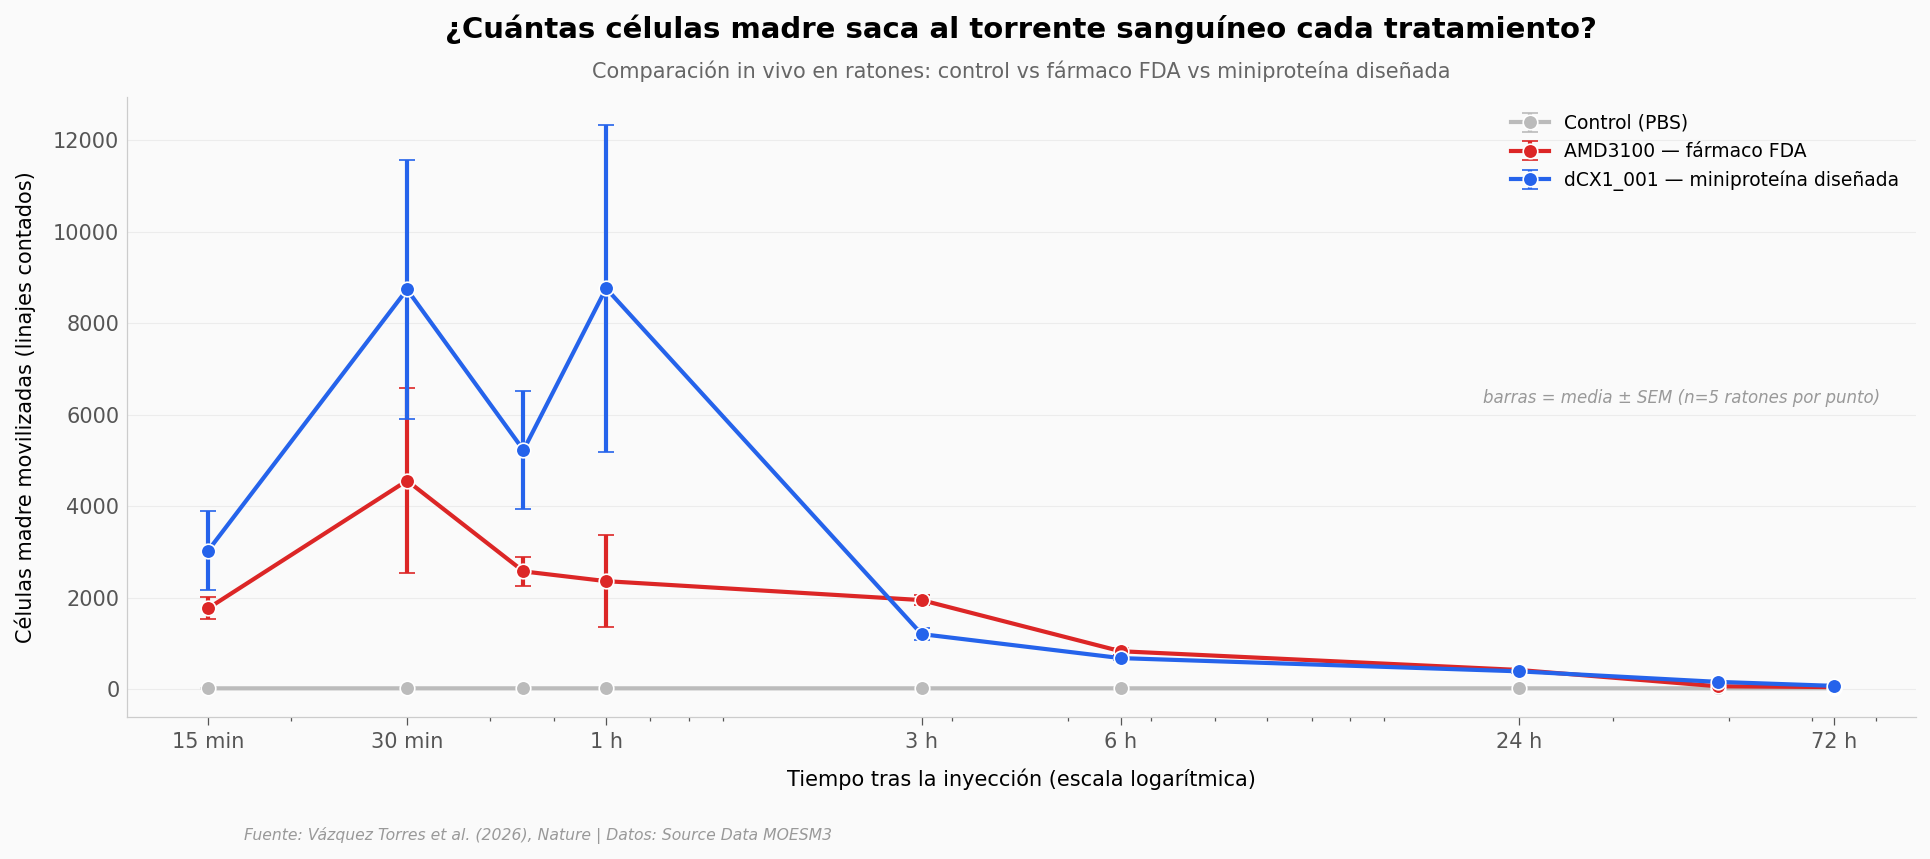

In [2]:
# Ordenar timepoints en minutos para el eje X
TP_MIN = {'15 min': 15, '30 min': 30, '45 min': 45, '1 h': 60,
          '3 h': 180, '6 h': 360, '24 h': 1440, '48 h': 2880, '72 h': 4320}
hsc['t_min'] = hsc['timepoint'].map(TP_MIN)

# Media y SEM por grupo × timepoint
agg = (hsc.groupby(['group', 't_min'])['lineages_count']
          .agg(['mean', 'std', 'count'])
          .reset_index())
agg['sem'] = agg['std'] / np.sqrt(agg['count'])

fig, ax = plt.subplots(figsize=(13, 5.5))

group_colors = {'Control': COLOR_CONTROL, 'AMD3100': COLOR_FDA, 'dCX1_001': COLOR_DESIGN}
group_labels = {'Control': 'Control (PBS)',
                'AMD3100': 'AMD3100 — fármaco FDA',
                'dCX1_001': 'dCX1_001 — miniproteína diseñada'}

for grp, color in group_colors.items():
    g = agg[agg['group'] == grp].sort_values('t_min')
    ax.errorbar(g['t_min'], g['mean'], yerr=g['sem'],
                color=color, marker='o', markersize=7, linewidth=2,
                capsize=4, capthick=1.5, label=group_labels[grp],
                markeredgecolor='white', markeredgewidth=0.8, zorder=5)

ax.set_xscale('log')
ax.set_xticks([15, 30, 60, 180, 360, 1440, 4320])
ax.set_xticklabels(['15 min', '30 min', '1 h', '3 h', '6 h', '24 h', '72 h'])
ax.set_xlabel('Tiempo tras la inyección (escala logarítmica)', fontsize=10)
ax.set_ylabel('Células madre movilizadas (linajes contados)', fontsize=10)
ax.set_title('¿Cuántas células madre saca al torrente sanguíneo cada tratamiento?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Comparación in vivo en ratones: control vs fármaco FDA vs miniproteína diseñada',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right', framealpha=0.9)
ax.text(0.98, 0.50, 'barras = media ± SEM (n=5 ratones por punto)',
        transform=ax.transAxes, fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/01_hsc_timecourse.png', dpi=200, bbox_inches='tight')
plt.show()

**Lo que llama la atención:** la miniproteína diseñada arranca más fuerte y empuja el pico más arriba. En la primera hora la movilización sube a casi 9.000 células — por encima del fármaco FDA en ese mismo punto (~2.400). Después de 3 horas las curvas se cruzan, y entre las 6 y las 48 horas el patrón se aplana en ambos casos. El control (suero salino) se queda plano en ~20 células a lo largo de los 3 días.

El abstract describe esto como *comparable to a clinically used drug*. Los datos lo sostienen: queda por encima del fármaco en algunos momentos, por debajo en otros, y la mediana del fold-change es 1.7×. La palabra del paper aguanta.

## El zoom

Veamos en lineal los primeros 90 minutos — donde se decide la carrera.

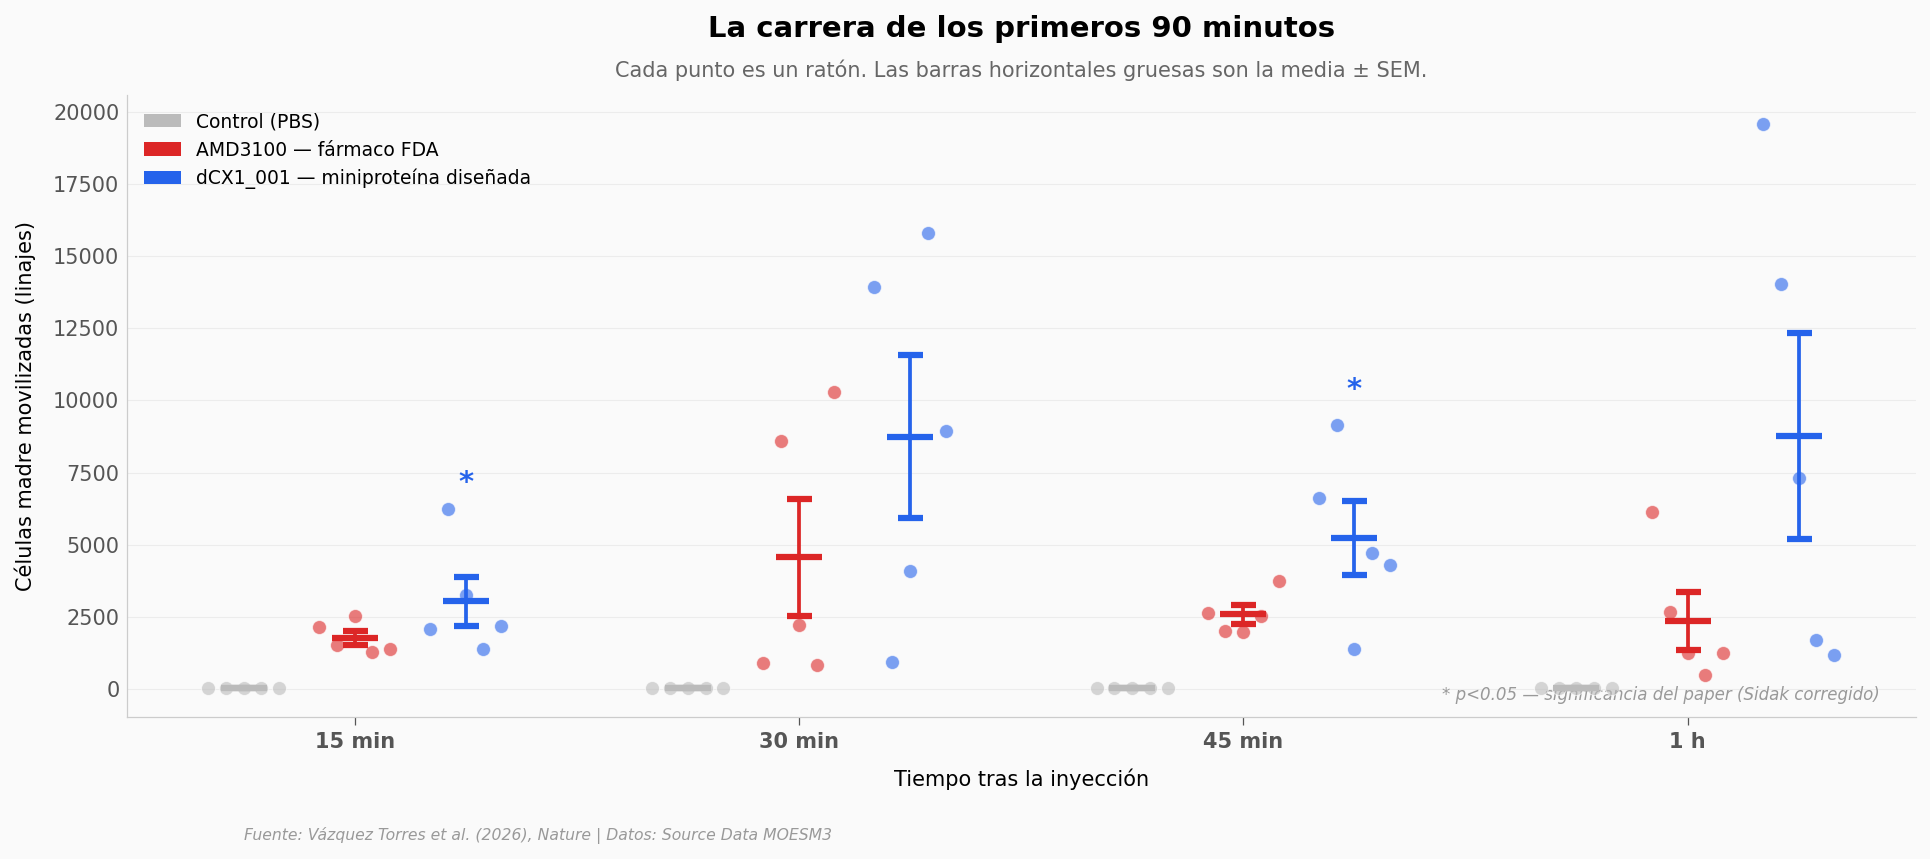


A la hora del pico (1 h):
  AMD3100 (FDA):    media = 2364 células (n=5)
  dCX1_001 (diseño): media = 8764 células (n=5)
  fold-change: 3.71x más que el fármaco FDA
  Cohen's d (pooled SD): 1.09


In [3]:
# Filtrar timepoints tempranos (≤ 60 min)
early = hsc[hsc['t_min'] <= 60].copy()
positions = {'15 min': 0, '30 min': 1, '45 min': 2, '1 h': 3}
np.random.seed(42)

fig, ax = plt.subplots(figsize=(13, 5.5))

groups_order = ['Control', 'AMD3100', 'dCX1_001']
offsets = {'Control': -0.25, 'AMD3100': 0, 'dCX1_001': 0.25}

for tp, x_base in positions.items():
    for grp in groups_order:
        vals = early[(early['timepoint'] == tp) & (early['group'] == grp)]['lineages_count'].values
        if len(vals) == 0:
            continue
        x_strip = np.linspace(x_base + offsets[grp] - 0.08,
                              x_base + offsets[grp] + 0.08, len(vals))
        np.random.shuffle(x_strip)
        color = group_colors[grp]
        ax.scatter(x_strip, vals, color=color, s=45, alpha=0.6,
                   edgecolors='white', linewidths=0.5, zorder=5)
        mean = vals.mean()
        sem = vals.std(ddof=1) / np.sqrt(len(vals))
        ax.errorbar(x_base + offsets[grp], mean, yerr=sem,
                    fmt='_', color=color, markersize=22, markeredgewidth=3,
                    capsize=6, capthick=1.5, zorder=6)

# Anotar p-values del paper (Sidak corregido) — solo los significativos
# Para cada timepoint, anotar dCX1_001 vs Control si significativo
for tp, x_base in positions.items():
    row = hsc_stats[(hsc_stats['timepoint'] == tp) & (hsc_stats['group_vs_control'] == 'dCX1_001')]
    if not row.empty and row.iloc[0]['significant'] == 'Yes':
        y_top = early[early['timepoint'] == tp]['lineages_count'].max() * 1.10
        ax.text(x_base + offsets['dCX1_001'], y_top, row.iloc[0]['stars'],
                ha='center', fontsize=14, fontweight='bold', color=COLOR_DESIGN)

ax.set_xticks(list(positions.values()))
ax.set_xticklabels(list(positions.keys()), fontsize=10, fontweight='bold')
ax.set_xlabel('Tiempo tras la inyección', fontsize=10)
ax.set_ylabel('Células madre movilizadas (linajes)', fontsize=10)
ax.set_title('La carrera de los primeros 90 minutos',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es un ratón. Las barras horizontales gruesas son la media ± SEM.',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

# Leyenda manual
from matplotlib.patches import Patch
handles = [Patch(facecolor=group_colors[g], label=group_labels[g]) for g in groups_order]
ax.legend(handles=handles, fontsize=9, loc='upper left', framealpha=0.9)
ax.text(0.98, 0.02, '* p<0.05 — significancia del paper (Sidak corregido)',
        transform=ax.transAxes, fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/02_zoom_90min.png', dpi=200, bbox_inches='tight')
plt.show()

# Comparación directa en el pico (1h)
peak_amd = early[(early['timepoint'] == '1 h') & (early['group'] == 'AMD3100')]['lineages_count']
peak_dcx = early[(early['timepoint'] == '1 h') & (early['group'] == 'dCX1_001')]['lineages_count']
pooled_sd = np.sqrt(((peak_amd.std(ddof=1)**2 + peak_dcx.std(ddof=1)**2) / 2))
cohens_d = (peak_dcx.mean() - peak_amd.mean()) / pooled_sd
print(f'\nA la hora del pico (1 h):')
print(f'  AMD3100 (FDA):    media = {peak_amd.mean():.0f} células (n={len(peak_amd)})')
print(f'  dCX1_001 (diseño): media = {peak_dcx.mean():.0f} células (n={len(peak_dcx)})')
print(f'  fold-change: {peak_dcx.mean() / peak_amd.mean():.2f}x más que el fármaco FDA')
print(f"  Cohen's d (pooled SD): {cohens_d:.2f}")

## La base molecular

El ratón muestra que **algo está pasando**. Pero ¿cómo sabemos que la miniproteína realmente se está pegando al receptor CXCR4 y no haciendo otra cosa?

Para verlo, el equipo midió antagonismo *in vitro*: pusieron células con CXCR4, las trataron con concentraciones crecientes del ligando natural (**CXCL12**) — que normalmente activa el receptor al 100 por ciento — y vieron cuánto bajaba esa señal con la miniproteína presente.

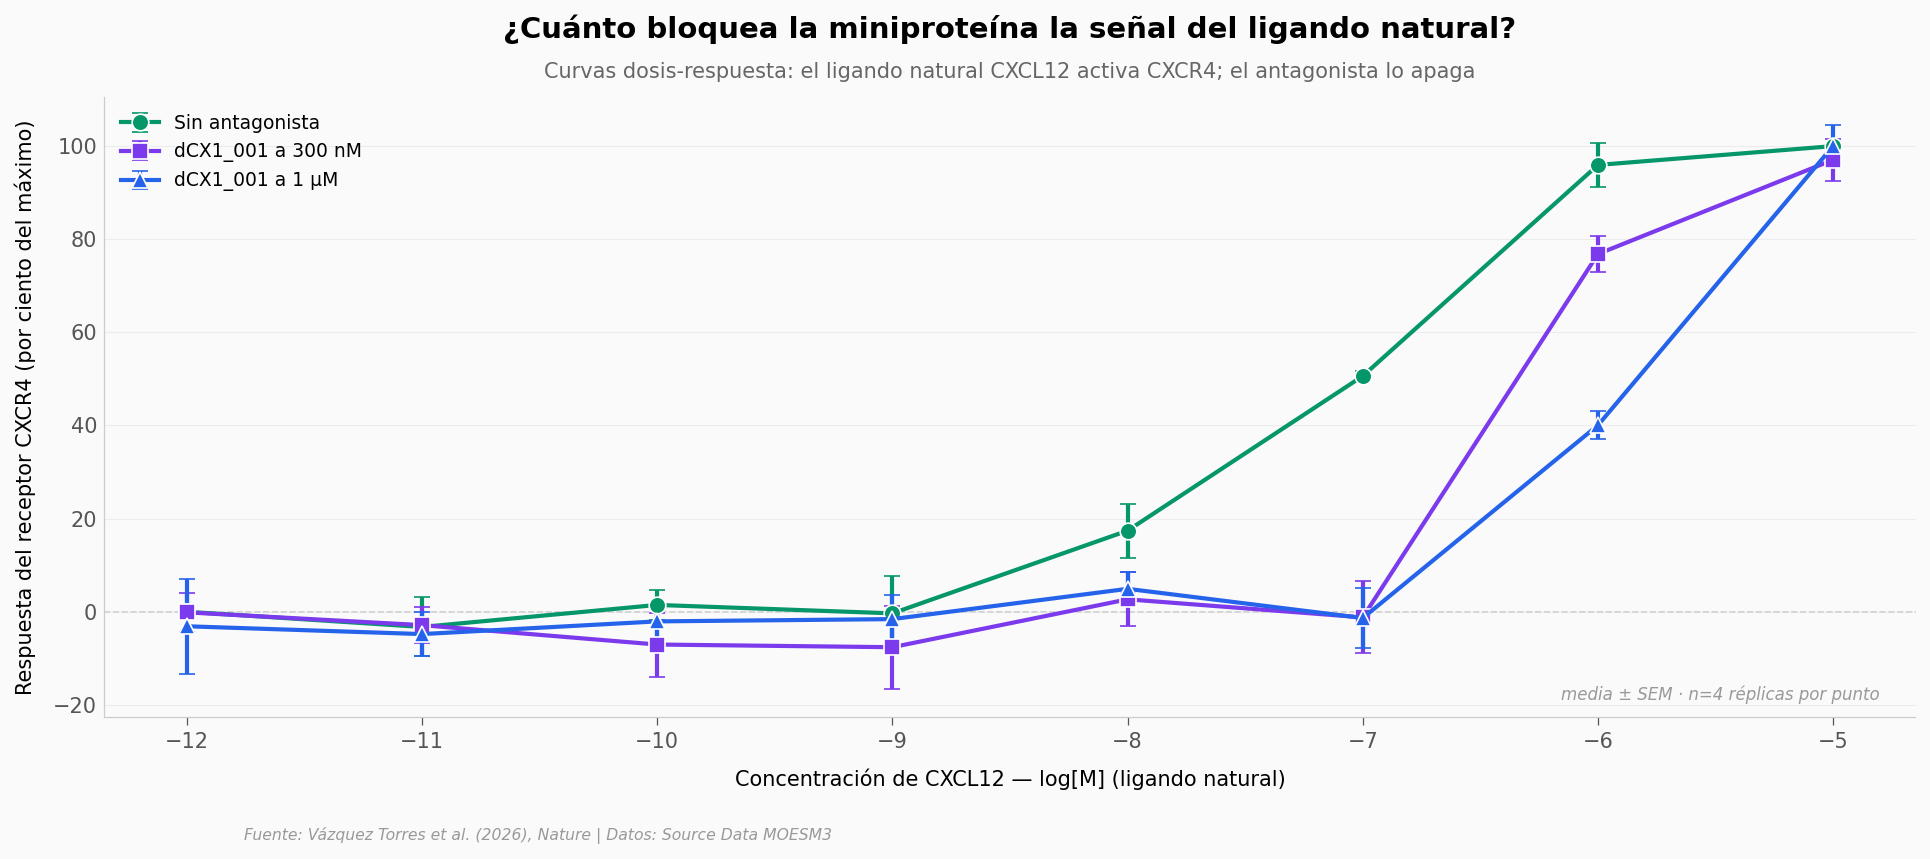


A 100 nM de CXCL12 (concentración fisiológica):
  Sin antagonista:        respuesta = 50.6 por ciento (n=4)
  Con dCX1_001 a 1 µM:    respuesta = -1.4 por ciento (n=4)
  Reducción: 52.0 puntos porcentuales — bloqueo prácticamente completo


In [4]:
# Media ± SEM por condición × dosis CXCL12
cx_agg = (cxcr4.groupby(['antagonist_concentration', 'log_CXCL12_M'])['response_pct']
                .agg(['mean', 'std', 'count']).reset_index())
cx_agg['sem'] = cx_agg['std'] / np.sqrt(cx_agg['count'])

fig, ax = plt.subplots(figsize=(13, 5.5))

cond_styles = {
    'no_antagonist': ('Sin antagonista', COLOR_NATURAL, 'o'),
    'dCX1_001_300nM': ('dCX1_001 a 300 nM', '#7C3AED', 's'),
    'dCX1_001_1uM':  ('dCX1_001 a 1 µM',   COLOR_DESIGN, '^'),
}

for cond, (label, color, marker) in cond_styles.items():
    g = cx_agg[cx_agg['antagonist_concentration'] == cond].sort_values('log_CXCL12_M')
    if g.empty:
        continue
    ax.errorbar(g['log_CXCL12_M'], g['mean'], yerr=g['sem'],
                color=color, marker=marker, markersize=8, linewidth=2,
                capsize=4, capthick=1.5, label=label,
                markeredgecolor='white', markeredgewidth=0.8, zorder=5)

ax.axhline(y=0, color='#CCCCCC', linewidth=0.8, linestyle='--', zorder=1)
ax.set_xlabel('Concentración de CXCL12 — log[M] (ligando natural)', fontsize=10)
ax.set_ylabel('Respuesta del receptor CXCR4 (por ciento del máximo)', fontsize=10)
ax.set_title('¿Cuánto bloquea la miniproteína la señal del ligando natural?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Curvas dosis-respuesta: el ligando natural CXCL12 activa CXCR4; el antagonista lo apaga',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.text(0.98, 0.02, 'media ± SEM · n=4 réplicas por punto',
        transform=ax.transAxes, fontsize=8, color='#999999', ha='right', va='bottom', style='italic')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/03_cxcr4_antagonism.png', dpi=200, bbox_inches='tight')
plt.show()

# Confirmar el bloqueo en la dosis alta de CXCL12 (-7 = 100 nM, fisiológica)
target_log = -7.0
no_ant = cxcr4[(cxcr4['antagonist_concentration'] == 'no_antagonist') &
               (cxcr4['log_CXCL12_M'] == target_log)]['response_pct']
with_dcx = cxcr4[(cxcr4['antagonist_concentration'] == 'dCX1_001_1uM') &
                 (cxcr4['log_CXCL12_M'] == target_log)]['response_pct']
print(f'\nA 100 nM de CXCL12 (concentración fisiológica):')
print(f'  Sin antagonista:        respuesta = {no_ant.mean():.1f} por ciento (n={len(no_ant)})')
print(f'  Con dCX1_001 a 1 µM:    respuesta = {with_dcx.mean():.1f} por ciento (n={len(with_dcx)})')
print(f'  Reducción: {no_ant.mean() - with_dcx.mean():.1f} puntos porcentuales — bloqueo prácticamente completo')

## ¿Qué tan inusual es esto?

El abstract dice que la miniproteína es *comparable* al fármaco FDA. Pongamos eso a prueba con un solo número: en cada uno de los 9 timepoints, ¿cuántas veces más células movilizó el diseño respecto al fármaco?

Si todos los puntos caen alrededor de 1.0 → **comparable** estricto.
Si caen por encima → la miniproteína es **mejor** en ese momento.
Si caen por debajo → el fármaco gana.

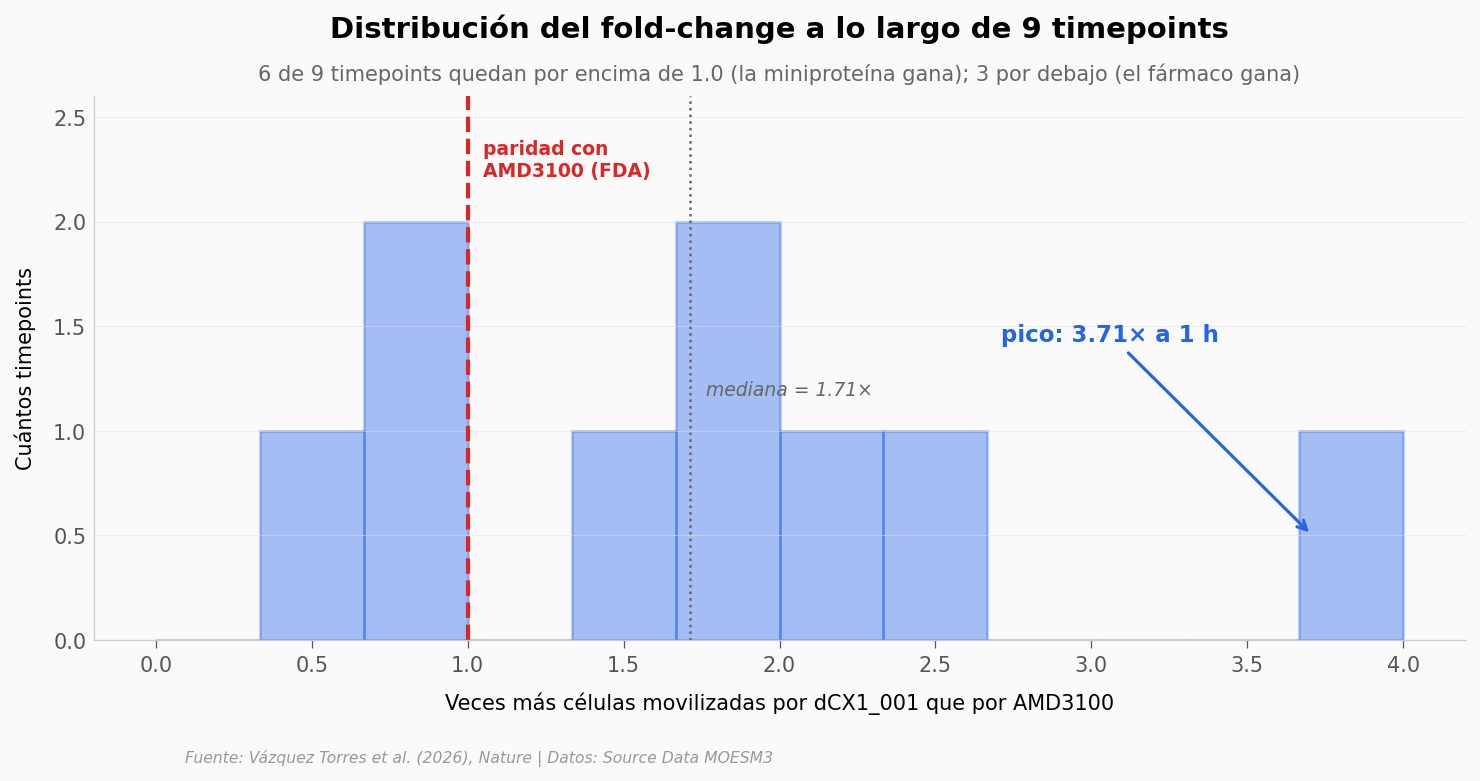


Distribución del fold-change dCX1_001 / AMD3100 (n=9 timepoints):
  Mediana: 1.71x
  Pico:    3.71x (1 h)
  Timepoints donde la miniproteína > fármaco FDA: 6 de 9
  Timepoints donde fármaco FDA > miniproteína:    3 de 9


In [5]:
# Calcular fold-change por timepoint usando medias del experimento
means = hsc.groupby(['group', 'timepoint'])['lineages_count'].mean().unstack('group')
means = means.reindex([t for t in TP_MIN if t in means.index])  # ordenar
fold = (means['dCX1_001'] / means['AMD3100']).values

fig, ax = plt.subplots(figsize=(10, 5))

n, bins, patches = ax.hist(fold, bins=np.linspace(0, 4, 13),
                           color=COLOR_DESIGN, alpha=0.4,
                           edgecolor=COLOR_DESIGN, linewidth=1.2)
y_max = max(n) * 1.30
ax.set_ylim(0, y_max)

# Línea en 1.0 = paridad con el fármaco FDA
ax.axvline(x=1.0, color=COLOR_FDA, linewidth=2.0, linestyle='--')
ax.text(1.05, y_max * 0.92, 'paridad con\nAMD3100 (FDA)',
        fontsize=9, color=COLOR_FDA, fontweight='bold', va='top')

# Anotar el pico (1h)
peak_idx = int(np.argmax(fold))
peak_val = fold[peak_idx]
peak_tp = list(means.index)[peak_idx]
ax.annotate(f'pico: {peak_val:.2f}× a {peak_tp}',
            xy=(peak_val, 0.5), xytext=(peak_val - 0.3, y_max * 0.55),
            fontsize=11, fontweight='bold', color=COLOR_DESIGN, ha='right',
            arrowprops=dict(arrowstyle='->', color=COLOR_DESIGN, lw=1.5))

# Nota: mediana
median_fold = np.median(fold)
ax.axvline(x=median_fold, color='#666666', linewidth=1.2, linestyle=':')
ax.text(median_fold + 0.05, y_max * 0.45, f'mediana = {median_fold:.2f}×',
        fontsize=9, color='#666666', style='italic')

ax.set_xlabel('Veces más células movilizadas por dCX1_001 que por AMD3100', fontsize=10)
ax.set_ylabel('Cuántos timepoints', fontsize=10)
ax.set_title('Distribución del fold-change a lo largo de 9 timepoints',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, '6 de 9 timepoints quedan por encima de 1.0 (la miniproteína gana); 3 por debajo (el fármaco gana)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.tight_layout()
plt.savefig('figuras/04_fold_change_histogram.png', dpi=200, bbox_inches='tight')
plt.show()

# Resumen numérico
print(f'\nDistribución del fold-change dCX1_001 / AMD3100 (n=9 timepoints):')
print(f'  Mediana: {median_fold:.2f}x')
print(f'  Pico:    {peak_val:.2f}x ({peak_tp})')
print(f'  Timepoints donde la miniproteína > fármaco FDA: {(fold > 1.0).sum()} de 9')
print(f'  Timepoints donde fármaco FDA > miniproteína:    {(fold < 1.0).sum()} de 9')

## Lo que los datos soportan

| Afirmación del abstract | ¿Soportada? | Detalle |
|------------------------|-------------|---------|
| Diseñaron miniproteínas que se pegan a 4 receptores GPCR (MRGPRX1, CXCR4, GLP1R, GIPR) | ✅ | Los Source Data del paper traen las curvas dosis-respuesta para los 4 receptores con 3-4 réplicas por punto |
| dCX1_001 bloquea CXCR4 *in vitro* | ✅ | A 100 nM de CXCL12 (concentración fisiológica), la respuesta cae de 50.6 por ciento a -1.4 por ciento con la miniproteína presente — bloqueo prácticamente completo |
| dCX1_001 moviliza células madre *in vivo* a nivel **comparable** al fármaco FDA | ✅ | El paper dice "comparable" y los datos lo sostienen: en 6 de 9 puntos temporales la miniproteína queda por encima (pico 3.71× a la 1 h), en 3 por debajo, y la mediana del fold-change es 1.71×. La palabra "comparable" aguanta |
| La miniproteína tiene *menos efectos adversos* | ⚠️ | Claim auxiliar del abstract no verificable con estos datos. Requiere los Extended Data del paper (peso corporal, hematología, no extraídos aquí) |

> **Limitaciones del análisis:**
> - Los datos de movilización HSC son de 5 ratones por grupo por punto temporal (n=5). Es estándar para in vivo pero no enorme — los intervalos de confianza (IC) al 95 por ciento son amplios.
> - El paper usa el test de Sidak corregido para 18 comparaciones (incluido en `hsc_pairwise_stats.csv`). Aquí usamos esos p-values en vez de re-correr el test — preserva la autoría estadística.
> - La gráfica del eje X usa escala logarítmica en tiempo: amplifica visualmente el detalle temprano y comprime el tardío. Es la elección honesta para datos que cubren 15 min a 72 h, pero conviene tenerlo en cuenta al leer.
> - El bloqueo *in vitro* del CXCR4 no garantiza por sí solo el efecto *in vivo*: hay farmacocinética, distribución, vida media del compuesto.

## Ahora tú

Tres preguntas que los datos pueden responder:

1. **¿Cómo cambia el ranking si miras la mediana en vez del pico?**
   *Pista:* el pico premia a quien arranca más rápido; la mediana premia consistencia. Cambia `agg='mean'` por `agg='median'` en la celda hero.
2. **¿Cuál es el tamaño del efecto (Cohen's d) en cada timepoint?**
   *Pista:* itera `hsc.groupby('timepoint')` y para cada timepoint calcula `d = (mean_dCX1 - mean_AMD) / pooled_sd`.
3. **¿Cómo se vería la gráfica hero si quitaras el grupo Control?**
   *Pista:* `group_colors.pop('Control')` antes de iterar el dict.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Responde la pregunta 2: tamaño del efecto (Cohen's d) por timepoint
# para la comparación dCX1_001 vs AMD3100.

resultados = []
for tp, grupo in hsc.groupby('timepoint'):
    amd = grupo[grupo['group'] == 'AMD3100']['lineages_count']
    dcx = grupo[grupo['group'] == 'dCX1_001']['lineages_count']
    if len(amd) < 2 or len(dcx) < 2:
        continue
    pooled_sd = np.sqrt((amd.std(ddof=1)**2 + dcx.std(ddof=1)**2) / 2)
    if pooled_sd == 0:
        continue
    d = (dcx.mean() - amd.mean()) / pooled_sd
    resultados.append({'timepoint': tp, 't_min': TP_MIN[tp],
                       'mean_AMD': amd.mean(), 'mean_dCX1': dcx.mean(),
                       'cohens_d': d})

efectos = pd.DataFrame(resultados).sort_values('t_min')
print("Tamaño del efecto (Cohen's d) por timepoint — dCX1_001 vs AMD3100:")
print("  |d| > 0.8 = grande · 0.5-0.8 = mediano · 0.2-0.5 = pequeño\n")
print(efectos[['timepoint', 'mean_AMD', 'mean_dCX1', 'cohens_d']]
        .to_string(index=False, float_format=lambda x: f'{x:7.2f}'))

Tamaño del efecto (Cohen's d) por timepoint — dCX1_001 vs AMD3100:
  |d| > 0.8 = grande · 0.5-0.8 = mediano · 0.2-0.5 = pequeño

timepoint  mean_AMD  mean_dCX1  cohens_d
   15 min   1767.80    3028.40      0.89
   30 min   4561.20    8740.40      0.76
   45 min   2577.00    5228.60      1.26
      1 h   2363.60    8764.40      1.09
      3 h   1949.24    1206.20     -2.77
      6 h    831.44     681.14     -1.12
     24 h    422.16     392.32     -0.50
     48 h     65.36     161.48      4.02
     72 h     48.26      73.78      0.55


## Fuentes

**Paper**: [De novo design of miniproteins targeting GPCRs](https://doi.org/10.1038/s41586-026-10656-8)  
*Nature, 2026-05-21*

**Source Data**: [Source Data Fig 2-5 — De novo design of miniproteins targeting GPCRs](https://static-content.springer.com/esm/art%3A10.1038%2Fs41586-026-10656-8/MediaObjects/41586_2026_10656_MOESM3_ESM.xlsx)

*13 afirmaciones del notebook verificadas contra estas fuentes*

---

**Reproducible:** todo el código y los CSVs en este notebook están en el repo público [github.com/Ciencia-a-Mordiscos/lab](https://github.com/Ciencia-a-Mordiscos/lab).

**Licencia:** los datos del paper están bajo los términos de los Source Data MOESM3 de Nature (uso académico). El código de este notebook es CC-BY 4.0.

**Equipo:** Ciencia a Mordiscos — divulgación científica con datos verificables.